In [20]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont

# Display norm

In [60]:
rec_seq = torch.load("model_outputs/rec_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [53]:
rec_seq = torch.load("model_outputs/ori_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [61]:
all_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_norm_list.append(norm_list)

In [39]:
len(all_norm_list)

10377

In [79]:
all_norm_list[9]

[0.9779276847839355,
 0.973573625087738,
 1.0275431871414185,
 0.40107983350753784,
 0.4880833625793457,
 0.6097118258476257,
 0.676997721195221,
 0.8470544219017029,
 0.7521040439605713,
 0.5765875577926636]

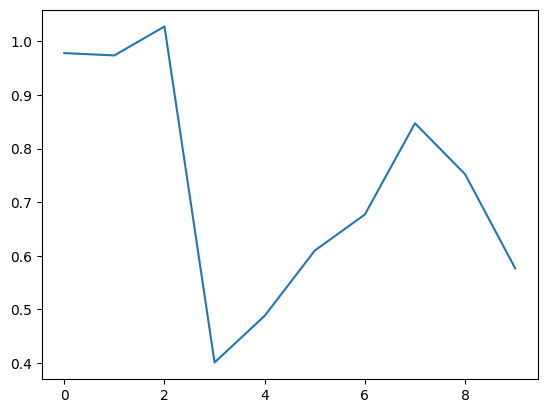

In [78]:
plot(range(10), all_norm_list[9])

# Find closest parts embedding

In [80]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

In [3]:
all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

In [4]:
all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

In [77]:
def find_closest(emb):
    delta = all_emb - emb
#     print(delta.shape)
    dist = LA.norm(delta, dim=1)
#     print(dist.shape)
    idx = dist.argmin()
#     print(dist[:10])
#     print(idx)
#     print(dist[idx])
    
    return idx.item()

In [81]:
all_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_closest_emb_list.append(closest_emb_list)

10it [00:02,  3.91it/s]


In [82]:
all_closest_emb_list

[[91286, 99916, 74102],
 [24160, 47198, 86656],
 [90792, 11038, 48540, 102414],
 [93995, 25065],
 [18003, 104101],
 [13875, 25043],
 [58667, 69556],
 [83671, 139079],
 [79231, 17919],
 [86655, 48717, 18786]]

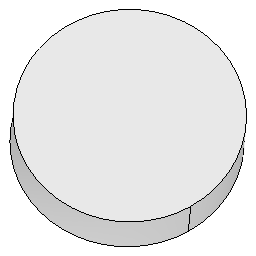

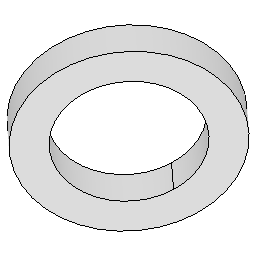

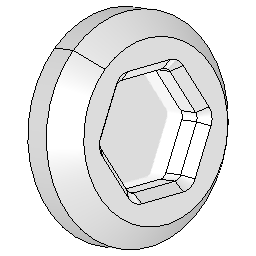

In [88]:
vid = "03"
for img_idx in all_closest_emb_list[9]:
    img_path = f'./raw_data/{vid}/{all_md[img_idx]}_00{vid}.png'
    img = Image.open(img_path)
    img.show()